# project03 - Complex leveraged strategies, multi-numeraire view

Three reference strategies from the brief:

1. **ETH/BTC**, leverage 3.0, debt = **BTC**
2. **ETH/BTC**, leverage 4.3, debt = **ETH**
3. **ETH/USDC**, leverage 5.0, debt = **USDC**

For each one we produce a single `polars` frame containing values in
the pool's quote asset, USD, ETH, BTC and USDC. No external price
feeds - all USD prices are part of the user-supplied scenario.

In [9]:
from lp_analysis import (
    AssetPair, PriceRange, PoolConfig, LendingPolicy, StrategyConfig,
    ScenarioPath, simulate, linear_price_sweep, to_frame, dashboard,
    plot_combined_equity, compute_pnl, liquidation_price_bounds,
)
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

## 1. Shared lending policy

Same CF/LF table across all three strategies so the comparison stays
fair. Replace these with your protocol's real values when running
production analysis.

In [10]:
lending = LendingPolicy(
    collateral_factors={'ETH': 0.80, 'BTC': 0.85, 'USDC': 0.90},
    liquidation_factors={'ETH': 0.85, 'BTC': 0.90, 'USDC': 0.95},
    borrow_apr_by_symbol={'ETH': 2.0, 'BTC': 1.5, 'USDC': 6.0},
    lp_protocol_factor=0.95,
)

## 2. Build the three strategies

In [11]:
pool_eth_btc = PoolConfig(
    pair=AssetPair('ETH', 'BTC'),
    price_initial=0.054,                       # BTC per ETH
    price_range=PriceRange(0.048, 0.060),
)
pool_eth_usdc = PoolConfig(
    pair=AssetPair('ETH', 'USDC'),
    price_initial=3500.0,                      # USDC per ETH
    price_range=PriceRange(3200.0, 3800.0),
)
s1 = StrategyConfig(name='ETH/BTC 3.0x BTC-debt',
                    pool=pool_eth_btc, lending=lending,
                    capital_asset1=1.0, leverage=3.0, debt_symbol='BTC')
s2 = StrategyConfig(name='ETH/BTC 4.3x ETH-debt',
                    pool=pool_eth_btc, lending=lending,
                    capital_asset1=1.0, leverage=4.3, debt_symbol='ETH')
s3 = StrategyConfig(name='ETH/USDC 5.0x USDC-debt',
                    pool=pool_eth_usdc, lending=lending,
                    capital_asset1=10_000.0, leverage=5.0, debt_symbol='USDC')

## 3. Define a scenario with consistent USD prices

Each strategy is driven by its own price sweep (n=400, t=180d). USD
prices are derived consistently so cross-rates match the swept pool price:
for the ETH/BTC strategies we hold BTC at a constant USD value and
compute ETH-USD via `eth_usd = pool_price * btc_usd`.

In [12]:
def scenario_for(strategy):
    sweep = linear_price_sweep(strategy, n_points=400, days_elapsed=180.0)
    n = sweep.n_steps
    pair = strategy.pool.pair
    usd = {'USDC': np.ones(n)}
    if pair == AssetPair('ETH', 'BTC'):
        btc_usd = np.full(n, 65_000.0)
        usd['BTC'] = btc_usd
        usd['ETH'] = sweep.price_path * btc_usd
    else:  # ETH/USDC pool
        usd['ETH'] = sweep.price_path.copy()
    return ScenarioPath(price_path=sweep.price_path,
                        t_days=sweep.t_days, usd_prices=usd)

results = {cfg.name: simulate(cfg, scenario_for(cfg)) for cfg in (s1, s2, s3)}

## 4. Multi-numeraire frame

The polars frame automatically produces `position_value_in_<sym>` and
`equity_in_<sym>` for every USD-priced symbol in the scenario.

In [13]:
df = to_frame(results['ETH/BTC 4.3x ETH-debt'])
df.select([
    'step', 'price', 't_days',
    'amount_ETH', 'amount_BTC',
    'debt_amount', 'debt_token',
    'position_value_asset1', 'equity_asset1',
    'position_value_usd', 'equity_usd',
    'equity_in_ETH', 'equity_in_BTC', 'equity_in_USDC',
    'margin_state',
]).head(10)

step,price,t_days,amount_ETH,amount_BTC,debt_amount,debt_token,position_value_asset1,equity_asset1,position_value_usd,equity_usd,equity_in_ETH,equity_in_BTC,equity_in_USDC,margin_state
i64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,str
0,0.0384,180.0,82.175553,0.0,61.716833,"""ETH""",3.155541,0.785615,205110.179983,51064.964693,20.45872,0.785615,51064.964693,"""healthy"""
1,0.038484,180.0,82.175553,0.0,61.716833,"""ETH""",3.162461,0.787338,205559.983009,51176.949265,20.45872,0.787338,51176.949265,"""healthy"""
2,0.038568,180.0,82.175553,0.0,61.716833,"""ETH""",3.169381,0.789061,206009.786035,51288.933836,20.45872,0.789061,51288.933836,"""healthy"""
3,0.038653,180.0,82.175553,0.0,61.716833,"""ETH""",3.176301,0.790783,206459.589061,51400.918408,20.45872,0.790783,51400.918408,"""healthy"""
4,0.038737,180.0,82.175553,0.0,61.716833,"""ETH""",3.183221,0.792506,206909.392088,51512.90298,20.45872,0.792506,51512.90298,"""healthy"""
5,0.038821,180.0,82.175553,0.0,61.716833,"""ETH""",3.190141,0.794229,207359.195114,51624.887551,20.45872,0.794229,51624.887551,"""healthy"""
6,0.038905,180.0,82.175553,0.0,61.716833,"""ETH""",3.197062,0.795952,207808.99814,51736.872123,20.45872,0.795952,51736.872123,"""healthy"""
7,0.038989,180.0,82.175553,0.0,61.716833,"""ETH""",3.203982,0.797675,208258.801166,51848.856695,20.45872,0.797675,51848.856695,"""healthy"""
8,0.039074,180.0,82.175553,0.0,61.716833,"""ETH""",3.210902,0.799398,208708.604193,51960.841267,20.45872,0.799398,51960.841267,"""healthy"""


## 5. Strategy-level dashboards


=== ETH/BTC 3.0x BTC-debt ===
  Liquidation prices  : {'lower': 0.038400000000000004, 'upper': 0.04345263157894737}
  PnL range (asset1)  : [-0.8133, +0.0619]
  PnL range (%)       : [-81.33%, +6.19%]


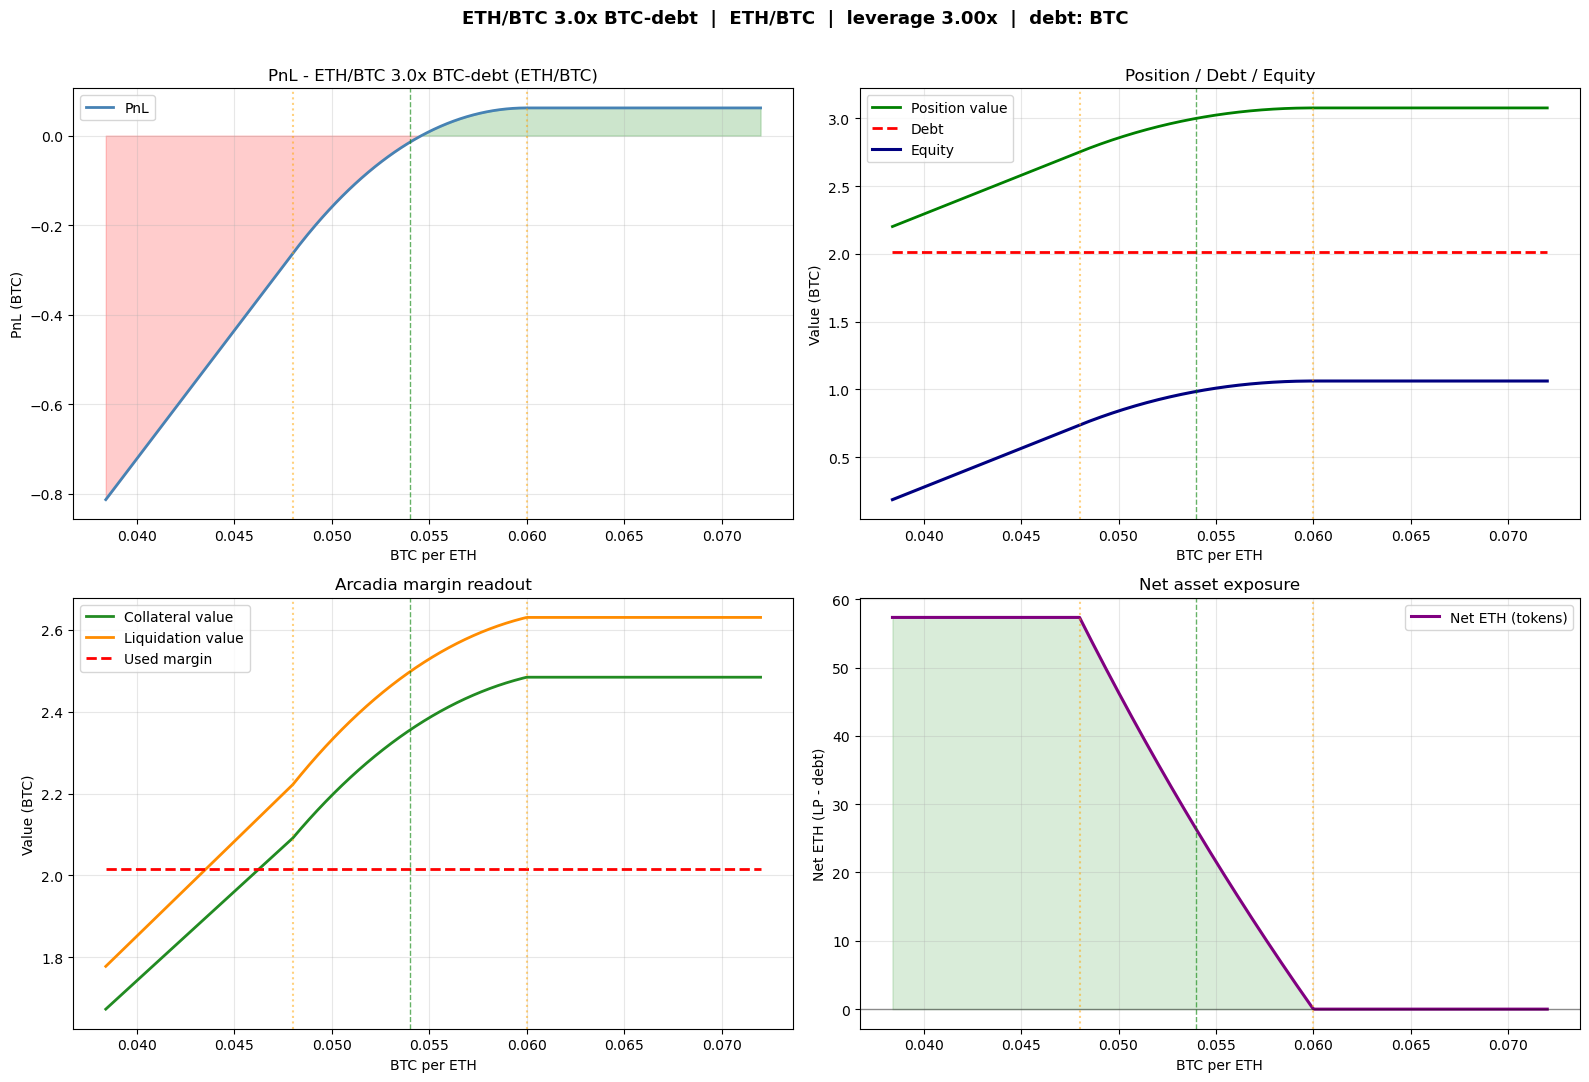


=== ETH/BTC 4.3x ETH-debt ===
  Liquidation prices  : {'lower': 0.061136842105263156, 'upper': 0.072}
  PnL range (asset1)  : [-1.0336, +0.0085]
  PnL range (%)       : [-103.36%, +0.85%]


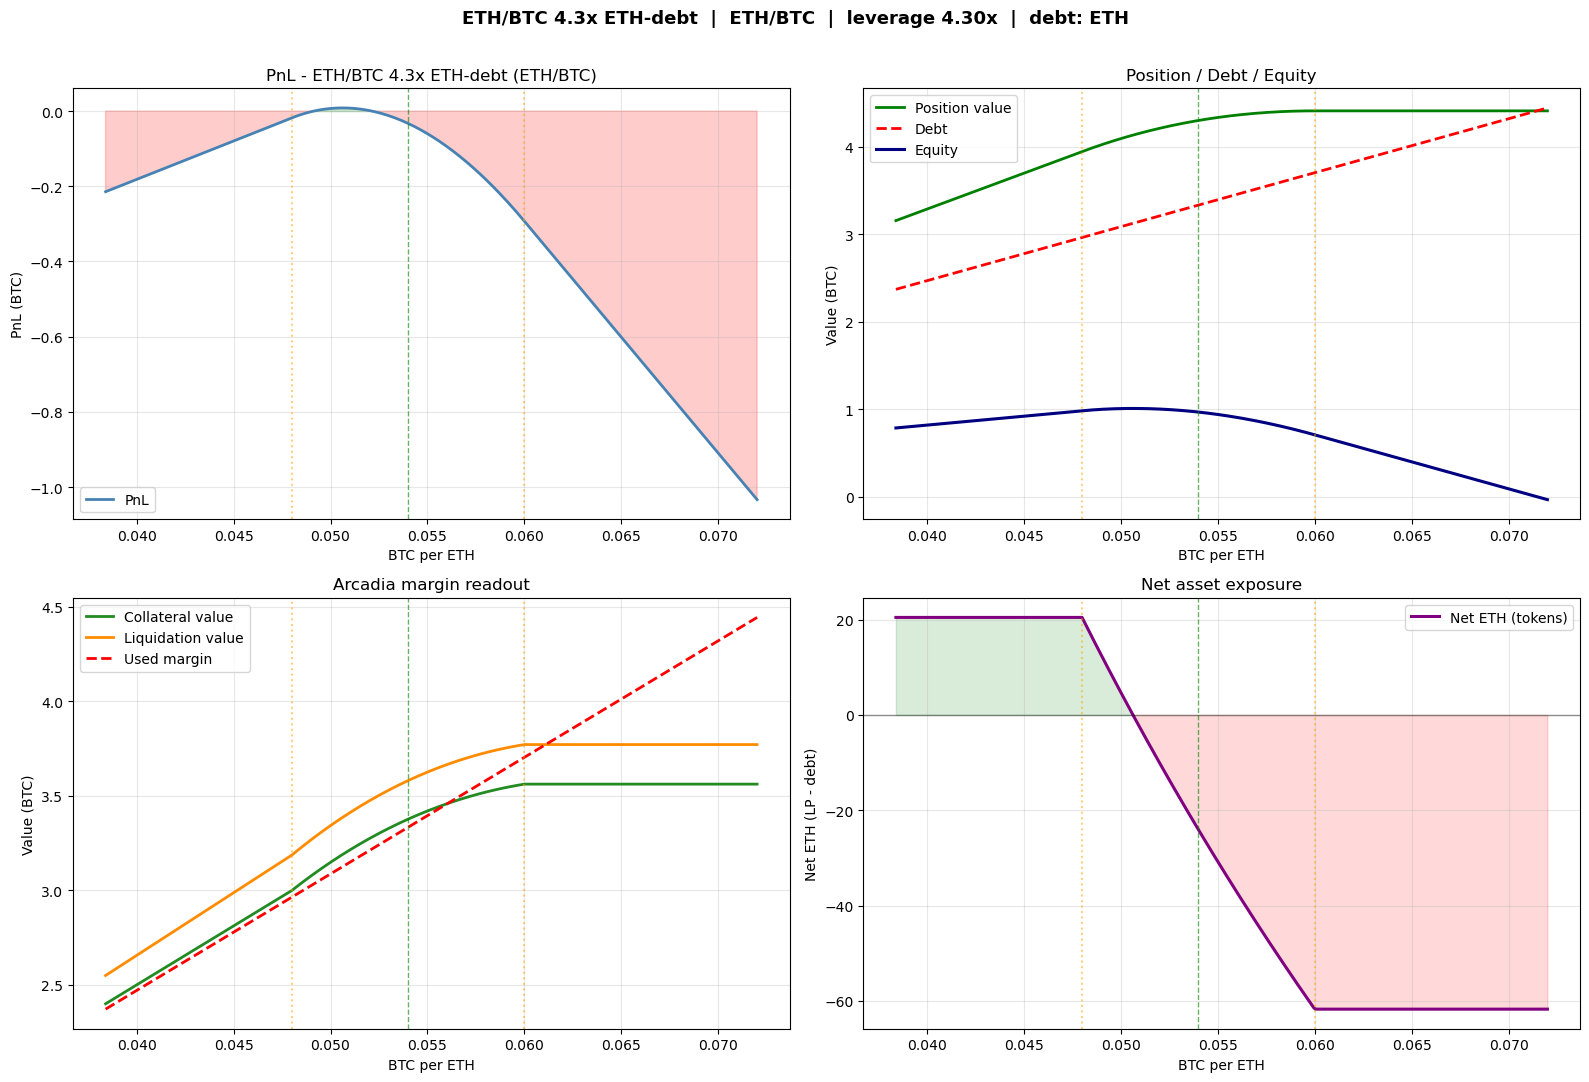


=== ETH/USDC 5.0x USDC-debt ===
  Liquidation prices  : {'lower': 2560.0, 'upper': 3387.0676691729323}
  PnL range (asset1)  : [-13,756.6833, -195.9133]
  PnL range (%)       : [-137.57%, -1.96%]


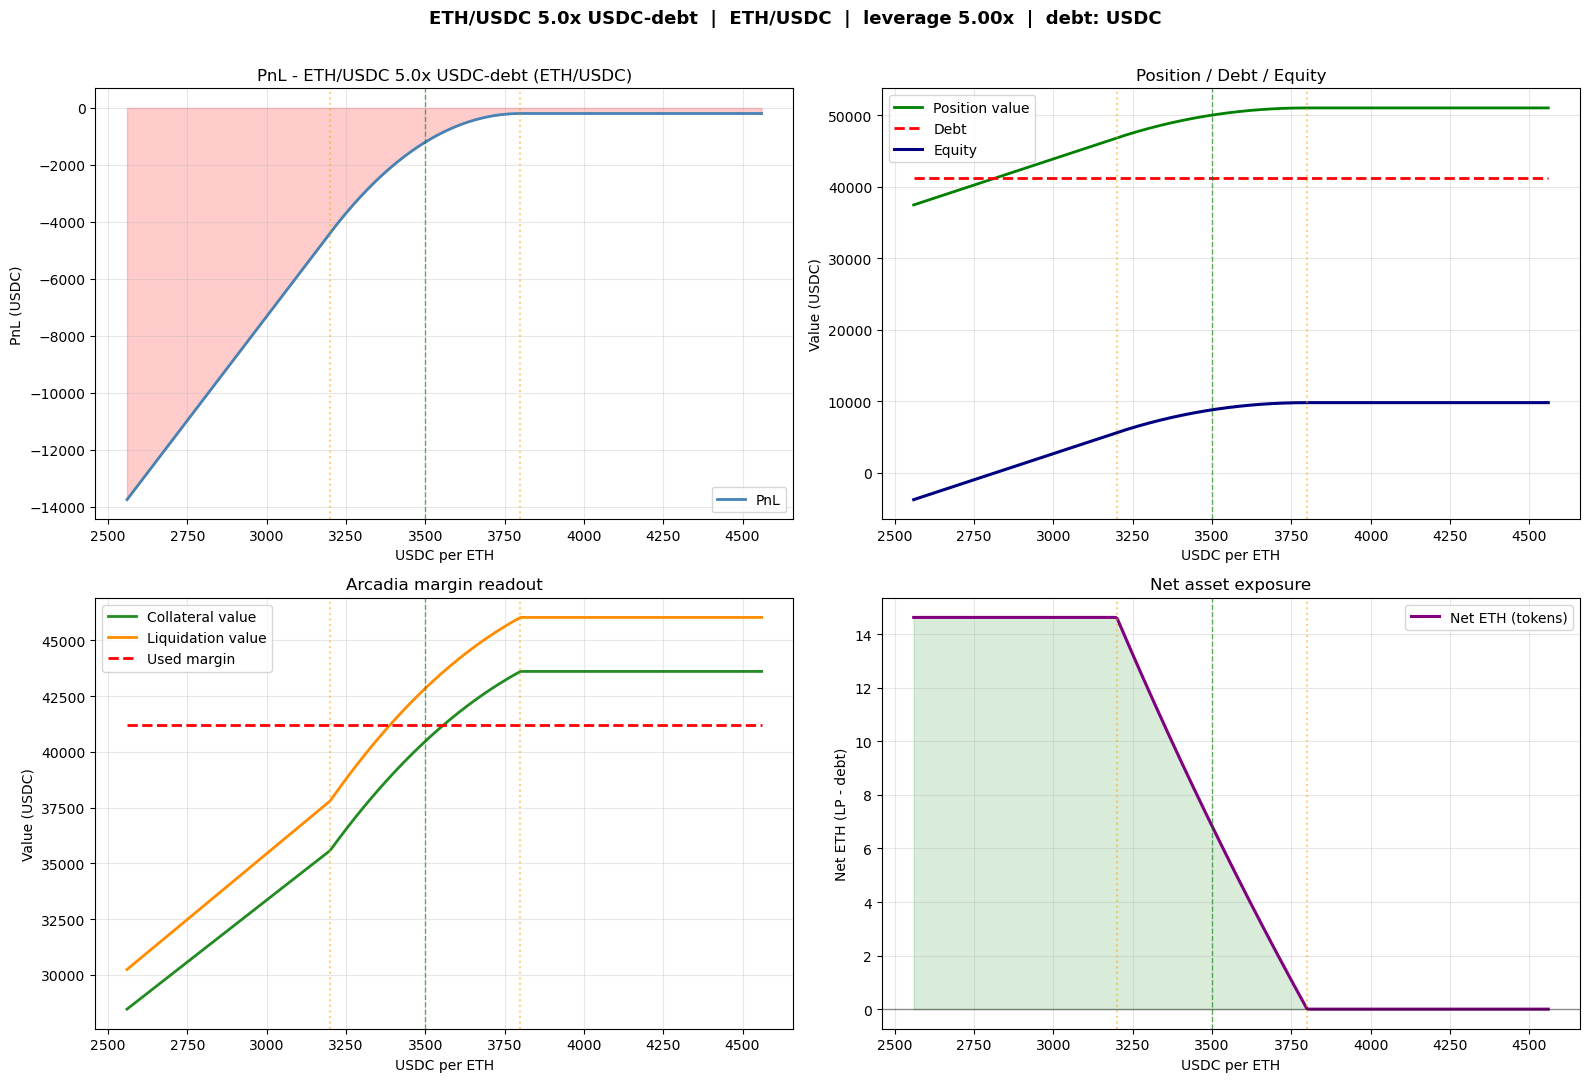

In [14]:
for name, result in results.items():
    print(f'\n=== {name} ===')
    print('  Liquidation prices  :', liquidation_price_bounds(result))
    pnl = compute_pnl(result)
    print(f'  PnL range (asset1)  : [{pnl.max_loss:+,.4f}, {pnl.max_gain:+,.4f}]')
    print(f'  PnL range (%)       : [{pnl.max_loss_pct:+.2f}%, {pnl.max_gain_pct:+.2f}%]')
    fig = dashboard(result)
    plt.show()

## 6. Combined portfolio - mix-and-match

Two strategies on the same pool can be plotted side-by-side along with
their portfolio sum.

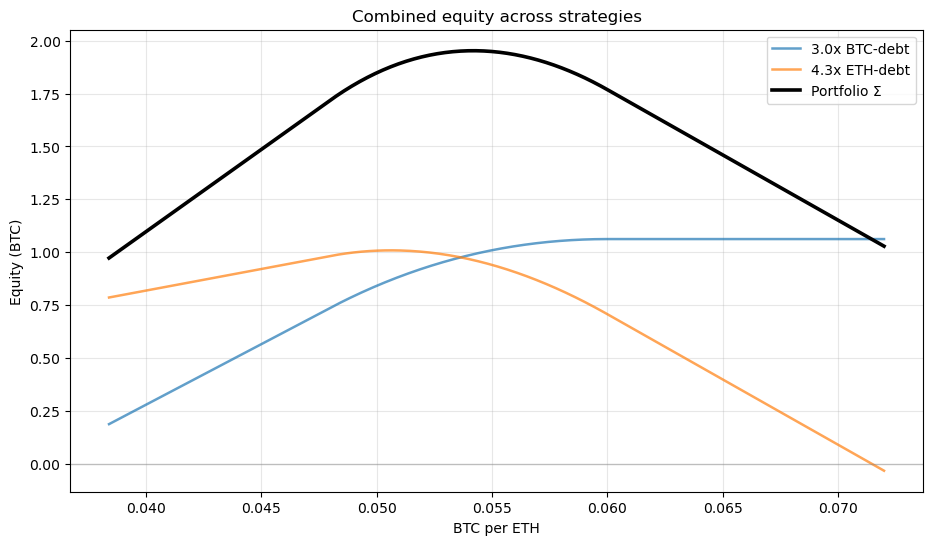

In [15]:
fig, ax = plt.subplots(figsize=(11, 6))
plot_combined_equity(
    [results['ETH/BTC 3.0x BTC-debt'], results['ETH/BTC 4.3x ETH-debt']],
    labels=['3.0x BTC-debt', '4.3x ETH-debt'],
    ax=ax,
)
plt.show()

## 7. Next steps

Extend in any direction without touching the core math:

* Use a non-linear `ScenarioPath` (historical pool prices, GBM sample paths,
  stress shocks) - just supply a different `price_path` and `t_days` array.
* Vary `lending` parameters per protocol (Arcadia vs Aave vs Moonwell) and
  inspect the same simulation through `arcadia_view`, `aave_view`,
  `moonwell_view`.
* Add more USD price paths in `ScenarioPath.usd_prices` to get equity
  reported in any numeraire you care about.